# Visualise data from ArcticDB

Run these cells from the Bluegrey repo with the `bluegrey` conda environment active.

Import ArcticDB. Import Path and sys to be able to find src/config.py and import the settings there.

In [1]:
# --- import ArcticDB module for client setup ---
from arcticdb import Arctic

# --- Modules to manage directories and paths ---
from pathlib import Path # -- for handling filesystem paths
import sys # -- for managing the Python path to ensure project modules can be imported

# --- Ensure repo root is on sys.path so that src/config.py can be imported ---
ROOT_DIR = Path.cwd()

while not (ROOT_DIR / "src").exists(): # -- traverse up the directory tree until we find a directory containing 'src/'
    if ROOT_DIR.parent == ROOT_DIR: # -- if we reach the root of the filesystem without finding 'src/', raise an error and exit to avoid infinite loop
        raise RuntimeError("Could not find repo root containing 'src/'")
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR)) # -- add repo root to sys.path at the start (to be read first) for module imports

# --- Now safe to import project config ---
import src.config.config as config


Connect to the ArcticDB database.

In [2]:
store = Arctic(config.ARCTIC_PATH)  # -- connect to ArcticDB store using path from config.

# If you run this line more than once you'll get a warning that the store is already initialized. You can ignore that if you're just running this notebook multiple times.

## --- Set the market & ticker frequency ---

In [3]:
# What market do you want to see? i.e. "fx", "equity", "crypto", "options", "indices".
market = "fx"

# What frequency do you want to see? i.e. "sec", "min", "hour", "day", "week", "month", "quarter", "year".
freq = "min"

Build the library name from asset type and frequency.
<br>
Load the corresponding dataset from the config.

In [4]:
# Combine to get the library name, e.g. "fx_min"Arctic
lib_name = f"{market}_{freq}"

lib = store[config.LIBS[lib_name]]  # -- access the specific library for minute-level FX data as defined in config

See what symbols are in the library

In [5]:
symbols = sorted(lib.list_symbols()) # -- get sorted list of all symbols in the library
print(symbols)

# # Uncomment the following to see the symbols as an array
# import numpy as np
# np.array(symbols)

['C:AUDCAD', 'C:AUDCHF', 'C:AUDEUR', 'C:AUDGBP', 'C:AUDHKD', 'C:AUDJPY', 'C:AUDMXN', 'C:AUDNOK', 'C:AUDNZD', 'C:AUDSEK', 'C:AUDSGD', 'C:AUDUSD', 'C:AUDZAR', 'C:CADAUD', 'C:CADCHF', 'C:CADEUR', 'C:CADGBP', 'C:CADHKD', 'C:CADJPY', 'C:CADMXN', 'C:CADNOK', 'C:CADNZD', 'C:CADSEK', 'C:CADSGD', 'C:CADUSD', 'C:CADZAR', 'C:CHFAUD', 'C:CHFCAD', 'C:CHFEUR', 'C:CHFGBP', 'C:CHFHKD', 'C:CHFJPY', 'C:CHFMXN', 'C:CHFNOK', 'C:CHFNZD', 'C:CHFSEK', 'C:CHFSGD', 'C:CHFUSD', 'C:CHFZAR', 'C:EURAUD', 'C:EURCAD', 'C:EURCHF', 'C:EURGBP', 'C:EURHKD', 'C:EURJPY', 'C:EURMXN', 'C:EURNOK', 'C:EURNZD', 'C:EURSEK', 'C:EURSGD', 'C:EURUSD', 'C:EURZAR', 'C:GBPAUD', 'C:GBPCAD', 'C:GBPCHF', 'C:GBPEUR', 'C:GBPHKD', 'C:GBPJPY', 'C:GBPMXN', 'C:GBPNOK', 'C:GBPNZD', 'C:GBPSEK', 'C:GBPSGD', 'C:GBPUSD', 'C:GBPZAR', 'C:HKDAUD', 'C:HKDCAD', 'C:HKDCHF', 'C:HKDEUR', 'C:HKDGBP', 'C:HKDJPY', 'C:HKDMXN', 'C:HKDNZD', 'C:HKDSEK', 'C:HKDSGD', 'C:HKDUSD', 'C:HKDZAR', 'C:JPYAUD', 'C:JPYCAD', 'C:JPYCHF', 'C:JPYEUR', 'C:JPYGBP', 'C:JPYHKD', 'C:

##  --- Set symbol ---

In [6]:
# Choose a symbol to visualize, e.g. "C:EURUSD", or "X:BTCUSD" for crypto. Make sure it exists in the library.
symbol = "C:EURUSD" # -- example for FX
# symbol = "X:BTCUSD" # -- example for crypto


Put the desired data from the Arctic database into a dataframe

In [7]:
# Fetch the data for the chosen symbol. This will return a DataFrame with columns like 'open', 'high', 'low', 'close', 'volume', etc.
df = lib.read(symbol).data
# df.head()
df

,open,high,low,close,volume,vwap
timestamp,,,,,,
2020-01-02 06:59:00,1.12068,1.12078,1.12065,1.12078,77,1.1207
2020-01-02 07:00:00,1.12079,1.12096,1.12078,1.12084,368,1.1209
2020-01-02 07:01:00,1.12085,1.12095,1.12084,1.12089,225,1.1209
2020-01-02 07:02:00,1.12089,1.12100,1.12086,1.12095,248,1.1209
2020-01-02 07:03:00,1.12095,1.12100,1.12089,1.12094,100,1.1209
...,...,...,...,...,...,...
2026-04-07 20:14:00,1.16007,1.16020,1.15998,1.16011,194,1.1601
2026-04-07 20:15:00,1.16015,1.16039,1.15988,1.16009,227,1.1601
2026-04-07 20:16:00,1.16011,1.16023,1.15990,1.16017,204,1.1601


Review brief statistics of dataframe

In [8]:
# --- Read and display basic statistics for the FX data ---
print("Data Summary Statistics:")
print(df.describe())
print("\nData Info:")
print(df.info())

Data Summary Statistics:
               open          high           low         close        volume  \
count  2.297919e+06  2.297919e+06  2.297919e+06  2.297919e+06  2.297919e+06   
mean   1.113673e+00  1.113785e+00  1.113500e+00  1.113672e+00  1.317805e+02   
std    5.722941e-02  5.722098e-02  5.724595e-02  5.722927e-02  1.333753e+02   
min    9.538700e-01  9.542700e-01  9.535700e-01  9.538600e-01  1.000000e+00   
25%    1.075700e+00  1.075820e+00  1.075500e+00  1.075700e+00  6.300000e+01   
50%    1.101800e+00  1.101900e+00  1.101620e+00  1.101800e+00  1.070000e+02   
75%    1.165020e+00  1.165130e+00  1.164900e+00  1.165020e+00  1.640000e+02   
max    1.234870e+00  1.234950e+00  1.234780e+00  1.234880e+00  8.924000e+03   

               vwap  
count  2.297919e+06  
mean   1.113674e+00  
std    5.722968e-02  
min    9.540000e-01  
25%    1.075700e+00  
50%    1.101800e+00  
75%    1.165000e+00  
max    1.234900e+00  

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 

Select a certain time-range of data to see

In [10]:
from pandas import to_datetime as to_datetime

initial_time = "2023-12-01"
final_time = "2024-01-01"
initial_final_range= (to_datetime(initial_time), to_datetime(final_time))

df_range = lib.read(
    symbol,
    date_range = initial_final_range
).data

# df_range.head()
df_range

,open,high,low,close,volume,vwap
timestamp,,,,,,
2023-12-01 00:00:00,1.08917,1.08928,1.08900,1.08920,63,1.0892
2023-12-01 00:01:00,1.08923,1.08933,1.08910,1.08931,57,1.0893
2023-12-01 00:02:00,1.08933,1.08940,1.08920,1.08939,57,1.0894
2023-12-01 00:03:00,1.08940,1.08942,1.08920,1.08940,64,1.0894
2023-12-01 00:04:00,1.08940,1.08947,1.08920,1.08945,64,1.0894
...,...,...,...,...,...,...
2023-12-29 21:56:00,1.10388,1.10390,1.10230,1.10230,60,1.1037
2023-12-29 21:57:00,1.10360,1.10390,1.10230,1.10390,11,1.1035
2023-12-29 21:58:00,1.10359,1.10409,1.10353,1.10360,16,1.1037


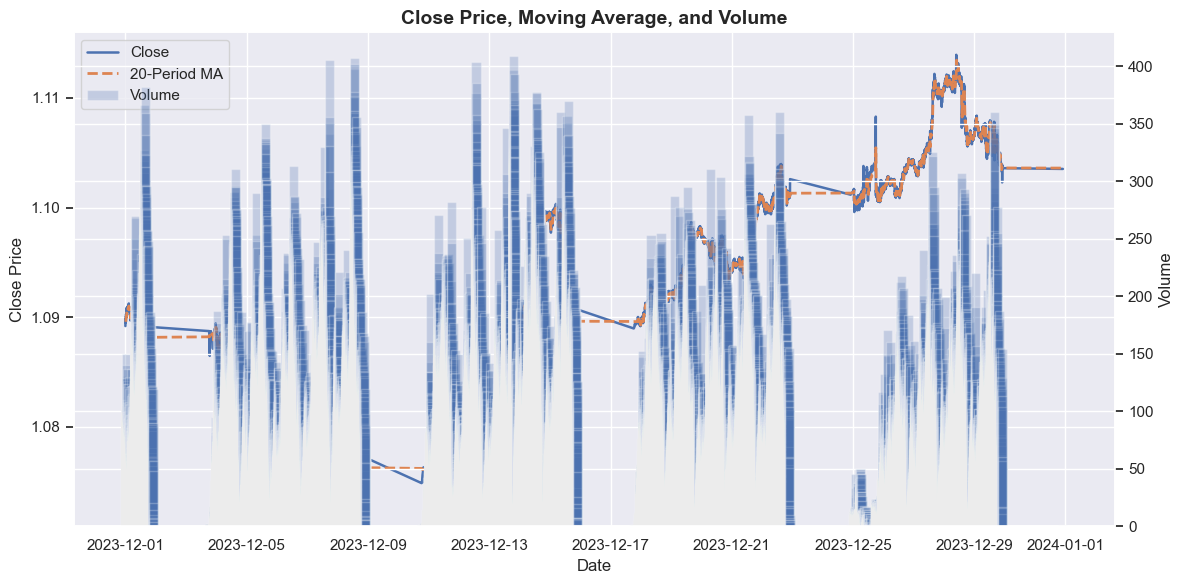

In [11]:
# Plot close, rolling MA, and volume using seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure datetime index
df_range.index = pd.to_datetime(df_range.index)

# Rolling average
ma_window = 20
df_range[f'close_ma_{ma_window}'] = df_range['close'].rolling(window=ma_window).mean()

# Seaborn styling
sns.set_theme(style="darkgrid", context="notebook")

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Close + MA (seaborn lines) ---
sns.lineplot(
    x=df_range.index,
    y=df_range['close'],
    ax=ax1,
    label='Close',
    linewidth=1.8
)

sns.lineplot(
    x=df_range.index,
    y=df_range[f'close_ma_{ma_window}'],
    ax=ax1,
    label=f'{ma_window}-Period MA',
    linewidth=2.0,
    linestyle='--'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')

# --- Volume (secondary axis, matplotlib bar) ---
ax2 = ax1.twinx()
ax2.bar(
    df_range.index,
    df_range['volume'],
    width=0.3,
    alpha=0.25,
    label='Volume'
)
ax2.set_ylabel('Volume')

# Title
ax1.set_title('Close Price, Moving Average, and Volume', fontsize=14, weight='bold')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Formatting
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

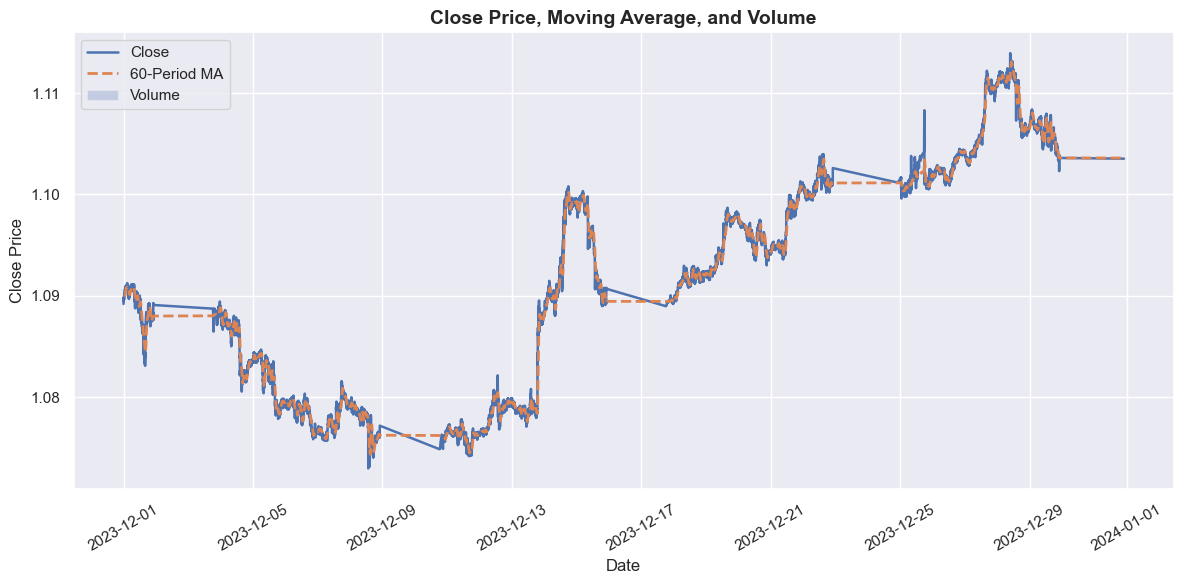

In [12]:
# Plot close, rolling MA, and volume using seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure datetime index
df_range.index = pd.to_datetime(df_range.index)

# Rolling average
ma_window = 60
df_range[f'close_ma_{ma_window}'] = df_range['close'].rolling(window=ma_window).mean()

# Seaborn styling
sns.set_theme(style="darkgrid", context="notebook")

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Close + MA (seaborn lines) ---
sns.lineplot(
    x=df_range.index,
    y=df_range['close'],
    ax=ax1,
    label='Close',
    linewidth=1.8
)

sns.lineplot(
    x=df_range.index,
    y=df_range[f'close_ma_{ma_window}'],
    ax=ax1,
    label=f'{ma_window}-Period MA',
    linewidth=2.0,
    linestyle='--'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')

# # --- Volume (secondary axis, matplotlib bar) ---
# ax2 = ax1.twinx()
# ax2.bar(
#     df_range.index,
#     df_range['volume'],
#     width=0.3,
#     alpha=0.25,
#     label='Volume'
# )
# ax2.set_ylabel('Volume')

# Title
ax1.set_title('Close Price, Moving Average, and Volume', fontsize=14, weight='bold')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Formatting
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()